# Module 3: SHAP Explainability
## Cardionova — Cardiovascular Risk Prediction System
### Making the Champion Model Interpretable for Clinical Use

**Author:** Pranjali Dangi (EN23CS301768)  
**Date:** March 2026  
**Model:** Logistic Regression (L1, C=0.175) — CV AUC: 0.7309

---

### Learning Objectives
After completing this module you will understand:
1. What SHAP values are and why they matter clinically
2. Global explainability — which features matter most ACROSS all patients
3. Local explainability — why the model predicted HIGH/LOW risk for ONE patient
4. How to use SHAP for clinical decision support


In [1]:
# ============================================================
# MODULE 3: SHAP EXPLAINABILITY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
plt.style.use('seaborn-v0_8-whitegrid')

print("=" * 60)
print("MODULE 3: SHAP EXPLAINABILITY")
print("=" * 60)
print(f"SHAP version: {shap.__version__}")
print("All libraries loaded successfully!")


MODULE 3: SHAP EXPLAINABILITY
SHAP version: 0.49.1
All libraries loaded successfully!


## Step 1: Load Champion Model & Data
Load the saved champion model from Module 2 and recreate the exact train/test split.


In [2]:
# ============================================================
# STEP 1: LOAD CHAMPION MODEL AND DATA
# ============================================================

# Load preprocessed data (from Module 1)
df = pd.read_csv('../framingham_processed.csv')

print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df['TenYearCHD'].value_counts()}")
print(f"\nFeature columns: {list(df.drop('TenYearCHD', axis=1).columns)}")


Dataset shape: (4240, 22)
Target distribution:
TenYearCHD
0.0000    3596
1.0000     644
Name: count, dtype: int64

Feature columns: ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'hypertension_stage', 'pack_years', 'pulse_pressure', 'cholesterol_risk', 'age_group', 'bmi_category']


In [7]:
import os

print("=== MODELS FOLDER ===")
for f in os.listdir('../models'):
    size = os.path.getsize(f'../models/{f}')
    print(f"  {f}  ({size/1024:.1f} KB)")

print("\n=== DATA FOLDER ===")
for f in os.listdir('../'):
    print(f"  {f}")



=== MODELS FOLDER ===
  cardionova_model.pkl  (1.5 KB)
  scaler.pkl  (598.2 KB)

=== DATA FOLDER ===
  framingham.csv
  framingham_processed.csv
  models
  notebooks
  reports
  src


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

# SAME random_state=42 as Module 2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Scaler ──────────────────────────────────────────────────
scaler_file = joblib.load('../models/scaler.pkl')
print(f"Scaler file type: {type(scaler_file)}")

if isinstance(scaler_file, dict):
    print(f"Keys found: {list(scaler_file.keys())}")
    # Try common key names
    scaler = (scaler_file.get('scaler') or 
              scaler_file.get('StandardScaler') or 
              list(scaler_file.values())[0])
else:
    scaler = scaler_file

print(f"Scaler object type: {type(scaler)}")

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert to DataFrame (SHAP needs feature names)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X.columns)

# ── Model ────────────────────────────────────────────────────
model_file = joblib.load('../models/cardionova_model.pkl')
print(f"\nModel file type: {type(model_file)}")

if isinstance(model_file, dict):
    print(f"Keys found: {list(model_file.keys())}")
    model = (model_file.get('model') or 
             model_file.get('LogisticRegression') or 
             list(model_file.values())[0])
else:
    model = model_file

print(f"Model object type: {type(model)}")

# ── Verify ───────────────────────────────────────────────────
print("\n" + "=" * 50)
print("CHAMPION MODEL LOADED SUCCESSFULLY")
print("=" * 50)
print(f"Model:      {type(model).__name__}")
print(f"Parameters: {model.get_params()}")
print(f"\nTrain set:  {X_train_scaled_df.shape}")
print(f"Test set:   {X_test_scaled_df.shape}")


Scaler file type: <class 'dict'>
Keys found: ['scaler', 'imputer', 'feature_names']
Scaler object type: <class 'sklearn.preprocessing._data.RobustScaler'>

Model file type: <class 'dict'>
Keys found: ['model', 'model_name', 'tuning_stage', 'feature_names', 'optimal_threshold', 'cv_auc', 'test_auc']
Model object type: <class 'sklearn.linear_model._logistic.LogisticRegression'>

CHAMPION MODEL LOADED SUCCESSFULLY
Model:      LogisticRegression
Parameters: {'C': 0.17473976635951144, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 3000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l1', 'random_state': 42, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

Train set:  (3392, 21)
Test set:   (848, 21)


## Step 2: Initialize SHAP Explainer

For Logistic Regression, we use `shap.LinearExplainer` which is:
- Fastest for linear models
- Analytically exact (not approximate)
- Returns SHAP values in log-odds space (then converted to probability space)

**Key Concept — What is a SHAP Value?**

If a patient's base prediction is 15% CVD risk:
- Age SHAP = +0.08 → Age pushes risk UP by 8% 
- BMI SHAP = -0.03 → BMI pushes risk DOWN by 3%
- Final prediction = 15% + 8% - 3% + ... = actual prediction

Every SHAP value is additive — they sum to the difference from the baseline.


In [9]:
# ============================================================
# STEP 2: INITIALIZE SHAP EXPLAINER
# ============================================================

# LinearExplainer is optimal for Logistic Regression
# interventional perturbation handles feature correlations correctly
explainer = shap.LinearExplainer(
    model, 
    X_train_scaled_df,
    feature_perturbation="interventional"
)

# Compute SHAP values for TEST SET
print("Computing SHAP values for test set...")
shap_values = explainer(X_test_scaled_df)

print("=" * 50)
print("SHAP VALUES COMPUTED SUCCESSFULLY")
print("=" * 50)
print(f"SHAP values shape: {shap_values.values.shape}")
print(f"  → {shap_values.values.shape[0]} patients")
print(f"  → {shap_values.values.shape[1]} features")
print(f"\nBase value (expected log-odds): {explainer.expected_value:.4f}")
print(f"Base rate in training set: {y_train.mean():.2%}")


Computing SHAP values for test set...
SHAP VALUES COMPUTED SUCCESSFULLY
SHAP values shape: (848, 21)
  → 848 patients
  → 21 features

Base value (expected log-odds): -0.3153
Base rate in training set: 15.18%


## Step 3: Global Explainability — Feature Importance

**Global SHAP Summary:**
- Shows which features matter MOST across ALL patients
- More reliable than model coefficients alone
- Captures DIRECTION of effect (positive/negative correlation with CVD risk)


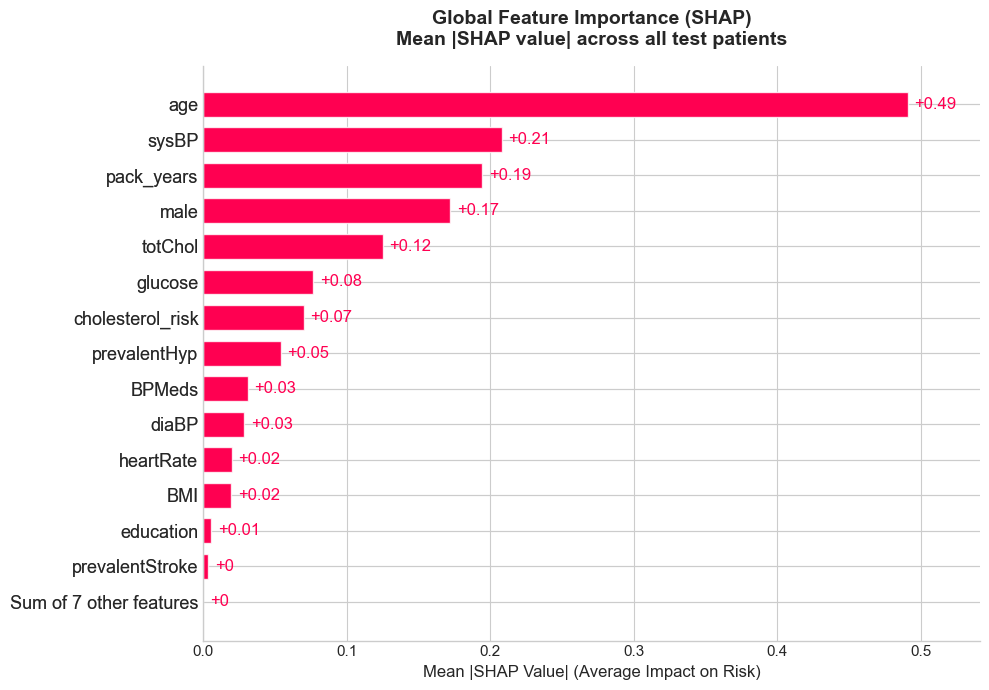

Saved: 09_shap_global_bar.png


In [10]:
# ============================================================
# STEP 3A: GLOBAL FEATURE IMPORTANCE — BAR PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

# Mean absolute SHAP values = global feature importance
shap.plots.bar(shap_values, max_display=15, show=False, ax=ax)

ax.set_title(
    'Global Feature Importance (SHAP)\n'
    'Mean |SHAP value| across all test patients',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Mean |SHAP Value| (Average Impact on Risk)', fontsize=12)

plt.tight_layout()
plt.savefig('../reports/09_shap_global_bar.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: 09_shap_global_bar.png")


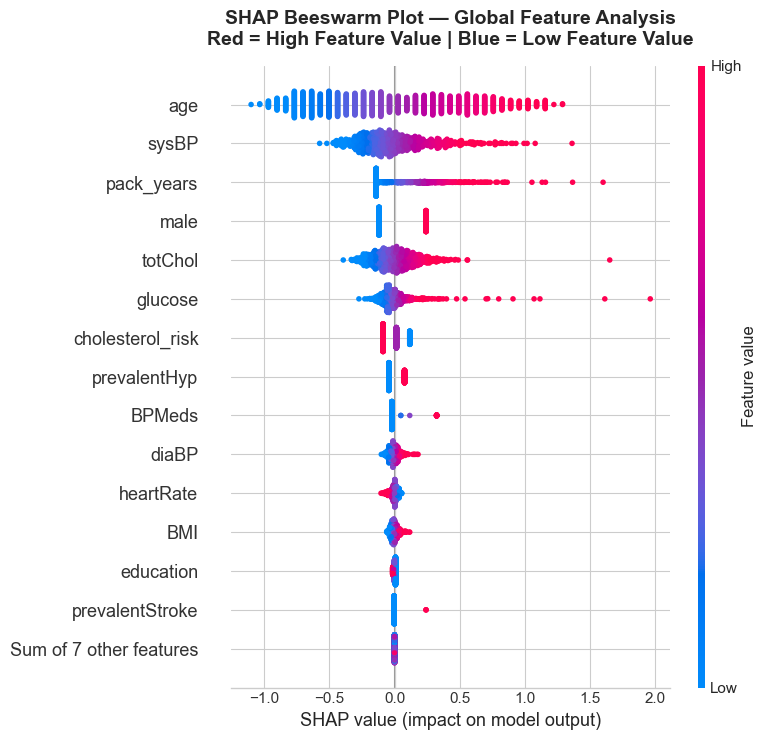

Saved: 10_shap_beeswarm.png

HOW TO READ THIS PLOT:
• Y-axis: Features ranked by importance (top = most important)
• X-axis: SHAP value (positive = increases CVD risk, negative = decreases)
• Color: Red = high feature value, Blue = low feature value

Example reading:
  Age (red dots on right) → High age → High CVD risk (as expected)
  Glucose (red on right)  → High glucose → High risk (diabetes effect)


In [11]:
# ============================================================
# STEP 3B: BEESWARM PLOT (Most Informative Global Plot)
# ============================================================
# Shows:
# - Feature importance (y-axis order)
# - Distribution of impact (x-axis spread)
# - Feature value direction (color: red=high feature value, blue=low)

fig, ax = plt.subplots(figsize=(12, 8))

shap.plots.beeswarm(shap_values, max_display=15, show=False)

plt.title(
    'SHAP Beeswarm Plot — Global Feature Analysis\n'
    'Red = High Feature Value | Blue = Low Feature Value',
    fontsize=14, fontweight='bold', pad=15
)

plt.tight_layout()
plt.savefig('../reports/10_shap_beeswarm.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: 10_shap_beeswarm.png")
print()
print("HOW TO READ THIS PLOT:")
print("• Y-axis: Features ranked by importance (top = most important)")
print("• X-axis: SHAP value (positive = increases CVD risk, negative = decreases)")
print("• Color: Red = high feature value, Blue = low feature value")
print()
print("Example reading:")
print("  Age (red dots on right) → High age → High CVD risk (as expected)")
print("  Glucose (red on right)  → High glucose → High risk (diabetes effect)")


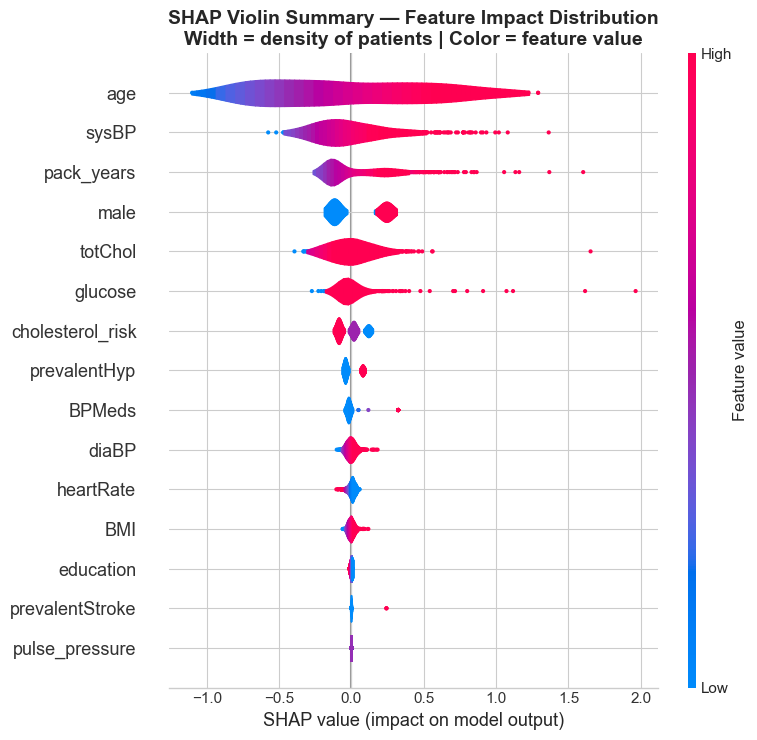

Saved: 11_shap_violin.png


In [12]:
# ============================================================
# STEP 3C: SHAP SUMMARY VIOLIN PLOT
# ============================================================

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values.values, 
    X_test_scaled_df,
    plot_type="violin",
    max_display=15,
    show=False
)

plt.title(
    'SHAP Violin Summary — Feature Impact Distribution\n'
    'Width = density of patients | Color = feature value',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../reports/11_shap_violin.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: 11_shap_violin.png")


In [13]:
# ============================================================
# STEP 3D: FEATURE IMPORTANCE TABLE (Export to CSV)
# ============================================================

# Calculate mean absolute SHAP values
feature_importance = pd.DataFrame({
    'Feature': X_test_scaled_df.columns,
    'Mean_Abs_SHAP': np.abs(shap_values.values).mean(axis=0),
    'Mean_SHAP': shap_values.values.mean(axis=0),
    'Std_SHAP': shap_values.values.std(axis=0),
    'LR_Coefficient': model.coef_[0]
})

feature_importance = feature_importance.sort_values('Mean_Abs_SHAP', ascending=False)
feature_importance['Rank'] = range(1, len(feature_importance) + 1)
feature_importance['Direction'] = feature_importance['Mean_SHAP'].apply(
    lambda x: '↑ Increases Risk' if x > 0 else '↓ Decreases Risk'
)

print("=" * 70)
print("GLOBAL FEATURE IMPORTANCE — SHAP RANKING")
print("=" * 70)
print(feature_importance[['Rank', 'Feature', 'Mean_Abs_SHAP', 'Direction', 'LR_Coefficient']].to_string())

# Save to CSV
feature_importance.to_csv('../reports/03_shap_feature_importance.csv', index=False)
print("\nSaved: 03_shap_feature_importance.csv")


GLOBAL FEATURE IMPORTANCE — SHAP RANKING
    Rank             Feature  Mean_Abs_SHAP         Direction  LR_Coefficient
1      1                 age         0.4909  ↓ Decreases Risk          0.9302
10     2               sysBP         0.2080  ↓ Decreases Risk          0.3324
16     3          pack_years         0.1943  ↑ Increases Risk          0.3577
0      4                male         0.1720  ↑ Increases Risk          0.3607
9      5             totChol         0.1249  ↑ Increases Risk          0.2011
14     6             glucose         0.0767  ↓ Decreases Risk          0.0935
18     7    cholesterol_risk         0.0698  ↓ Decreases Risk         -0.1026
7      8        prevalentHyp         0.0538  ↓ Decreases Risk          0.1203
5      9              BPMeds         0.0308  ↓ Decreases Risk          0.3441
11    10               diaBP         0.0285  ↓ Decreases Risk          0.0463
13    11           heartRate         0.0197  ↑ Increases Risk         -0.0318
12    12               

## Step 4: SHAP Dependence Plots

**Dependence Plots** show:
- How ONE feature's SHAP value changes across its value range
- Whether the relationship is linear or non-linear
- Interaction effects with other features (color)

We'll analyze the TOP 3 most important features.


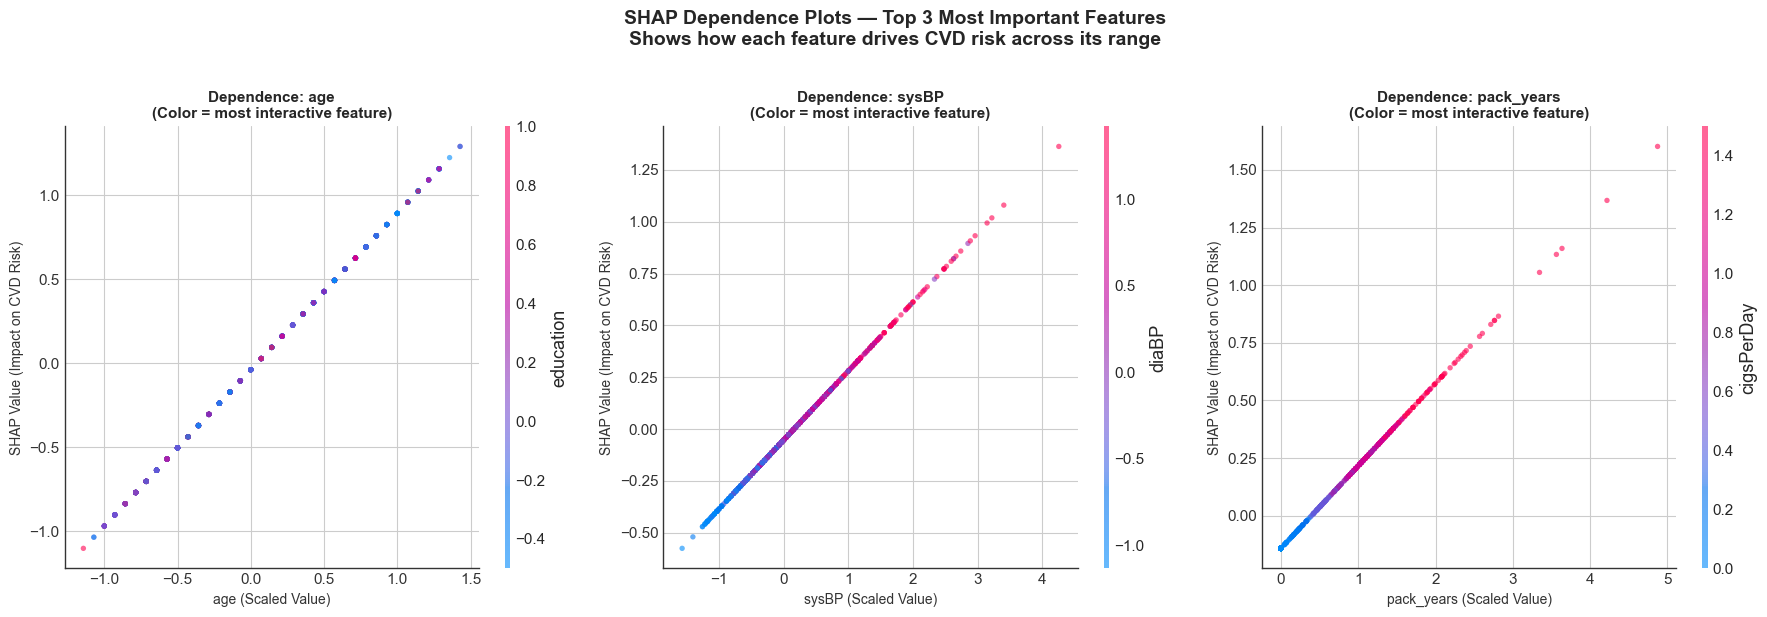

Saved: 12_shap_dependence.png


In [14]:
# ============================================================
# STEP 4: SHAP DEPENDENCE PLOTS — Top 3 Features
# ============================================================

top3_features = feature_importance.head(3)['Feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(top3_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X_test_scaled_df,
        ax=axes[i],
        show=False,
        dot_size=15,
        alpha=0.6
    )
    axes[i].set_title(
        f'Dependence: {feature}\n(Color = most interactive feature)',
        fontsize=11, fontweight='bold'
    )
    axes[i].set_xlabel(f'{feature} (Scaled Value)', fontsize=10)
    axes[i].set_ylabel('SHAP Value (Impact on CVD Risk)', fontsize=10)

plt.suptitle(
    'SHAP Dependence Plots — Top 3 Most Important Features\n'
    'Shows how each feature drives CVD risk across its range',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../reports/12_shap_dependence.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: 12_shap_dependence.png")


## Step 5: Local Explainability — Individual Patient Predictions

**Local explanations** answer: *"Why did the model give THIS patient a high/low risk score?"*

This is the most clinically valuable part — doctors want to know what's SPECIFICALLY driving risk for THEIR patient.

We will analyze:
1. **High Risk Patient** — Model predicted HIGH CVD risk → why?
2. **Low Risk Patient** — Model predicted LOW CVD risk → why?
3. **Borderline Patient** — Near decision threshold → what tipped the scale?


In [15]:
# ============================================================
# STEP 5A: SELECT REPRESENTATIVE PATIENTS
# ============================================================

# Get predicted probabilities for all test patients
y_prob = model.predict_proba(X_test_scaled_df)[:, 1]
y_pred = model.predict(X_test_scaled_df)

# Create results dataframe
results_df = pd.DataFrame({
    'True_Label': y_test.values,
    'Predicted_Label': y_pred,
    'CVD_Probability': y_prob
})

# Find representative patients
high_risk_idx = results_df[
    (results_df['True_Label'] == 1) & 
    (results_df['CVD_Probability'] > 0.75)
].index[0]

low_risk_idx = results_df[
    (results_df['True_Label'] == 0) & 
    (results_df['CVD_Probability'] < 0.15)
].index[0]

borderline_idx = results_df[
    (results_df['CVD_Probability'] > 0.45) & 
    (results_df['CVD_Probability'] < 0.55)
].index[0]

print("=" * 60)
print("REPRESENTATIVE PATIENTS SELECTED")
print("=" * 60)

for name, idx in [("HIGH RISK", high_risk_idx), 
                   ("LOW RISK", low_risk_idx), 
                   ("BORDERLINE", borderline_idx)]:
    prob = results_df.loc[idx, 'CVD_Probability']
    true = results_df.loc[idx, 'True_Label']
    print(f"\n{name} Patient (index {idx}):")
    print(f"  CVD Probability: {prob:.2%}")
    print(f"  True Label:      {'CVD' if true == 1 else 'No CVD'}")
    print(f"  Correct Prediction: {'YES' if (prob>0.5)==bool(true) else 'NO'}")


REPRESENTATIVE PATIENTS SELECTED

HIGH RISK Patient (index 62):
  CVD Probability: 88.19%
  True Label:      CVD
  Correct Prediction: YES

LOW RISK Patient (index 8):
  CVD Probability: 13.45%
  True Label:      No CVD
  Correct Prediction: YES

BORDERLINE Patient (index 2):
  CVD Probability: 52.61%
  True Label:      No CVD
  Correct Prediction: NO


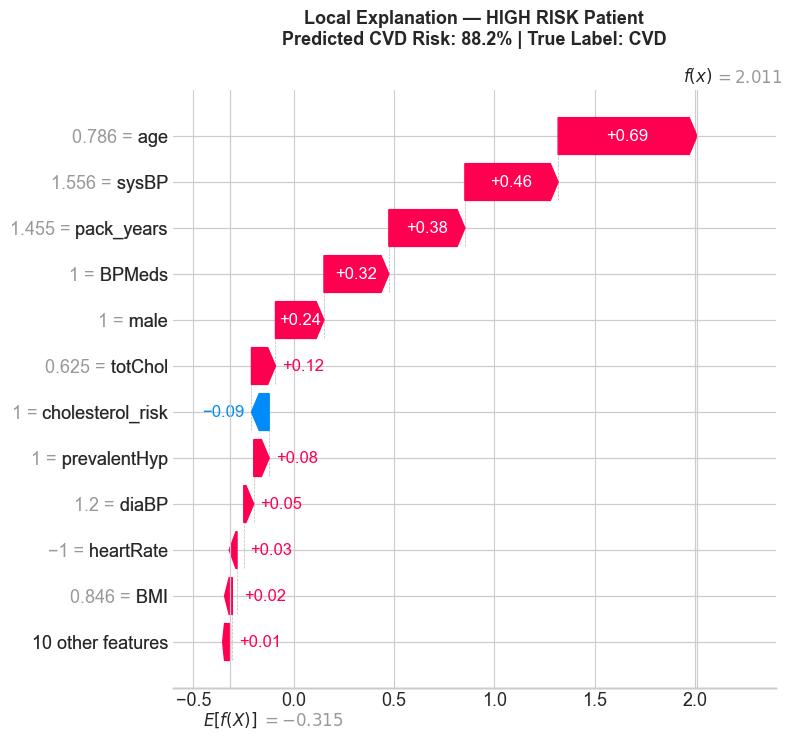

Saved: ../reports/13_shap_waterfall_high_risk.png
  Patient CVD Probability: 88.19%



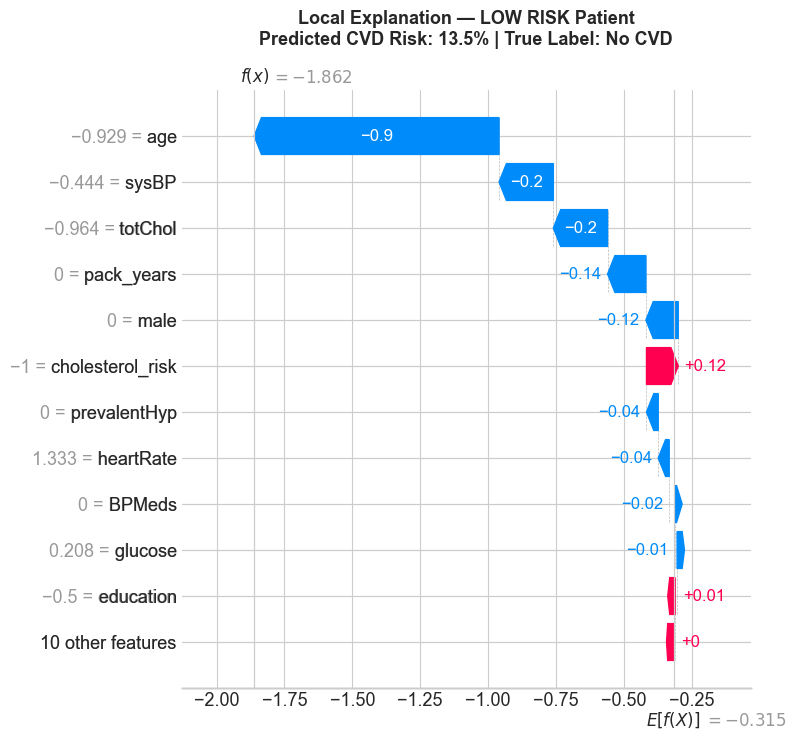

Saved: ../reports/13_shap_waterfall_low_risk.png
  Patient CVD Probability: 13.45%



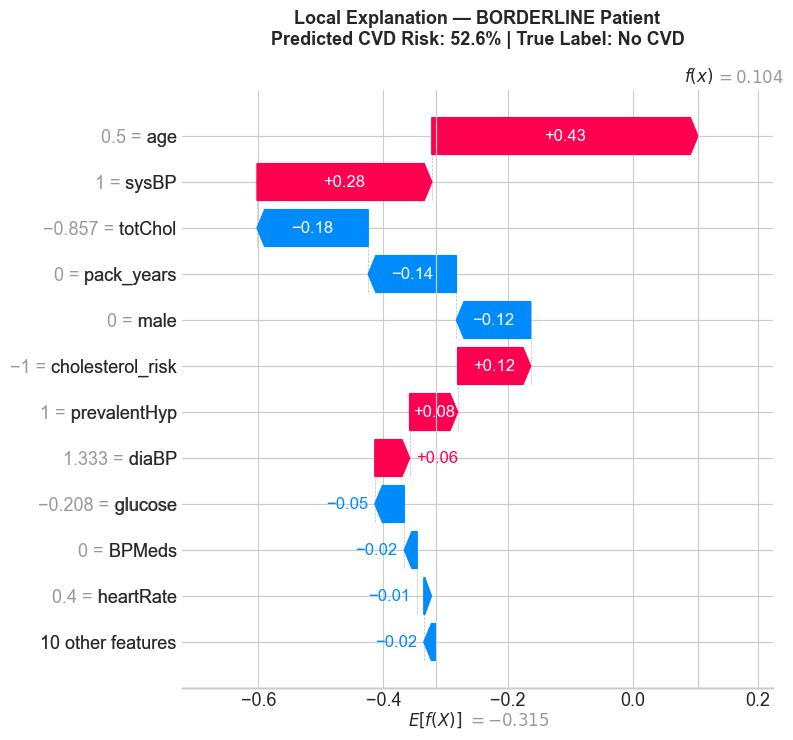

Saved: ../reports/13_shap_waterfall_borderline.png
  Patient CVD Probability: 52.61%

HOW TO READ WATERFALL PLOTS:
• RED bars = Features INCREASING CVD risk
• BLUE bars = Features DECREASING CVD risk
• Bar length = magnitude of effect
• Bottom E[f(X)] = baseline/average prediction
• Top f(x) = final prediction for this patient


In [16]:
# ============================================================
# STEP 5B: WATERFALL PLOTS (Best Local Explanation)
# ============================================================

patients = {
    'HIGH_RISK': high_risk_idx,
    'LOW_RISK': low_risk_idx, 
    'BORDERLINE': borderline_idx
}

for name, idx in patients.items():
    fig, ax = plt.subplots(figsize=(12, 7))
    
    prob = results_df.loc[idx, 'CVD_Probability']
    true_label = results_df.loc[idx, 'True_Label']
    
    # Get index position in test set
    pos = list(X_test_scaled_df.index).index(idx)
    
    shap.plots.waterfall(shap_values[pos], max_display=12, show=False)
    
    plt.title(
        f'Local Explanation — {name.replace("_", " ")} Patient\n'
        f'Predicted CVD Risk: {prob:.1%} | True Label: {"CVD" if true_label==1 else "No CVD"}',
        fontsize=13, fontweight='bold', pad=15
    )
    
    plt.tight_layout()
    filename = f'../reports/13_shap_waterfall_{name.lower()}.png'
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()
    
    print(f"Saved: {filename}")
    print(f"  Patient CVD Probability: {prob:.2%}")
    print()

print("HOW TO READ WATERFALL PLOTS:")
print("• RED bars = Features INCREASING CVD risk")
print("• BLUE bars = Features DECREASING CVD risk")
print("• Bar length = magnitude of effect")
print("• Bottom E[f(X)] = baseline/average prediction")
print("• Top f(x) = final prediction for this patient")


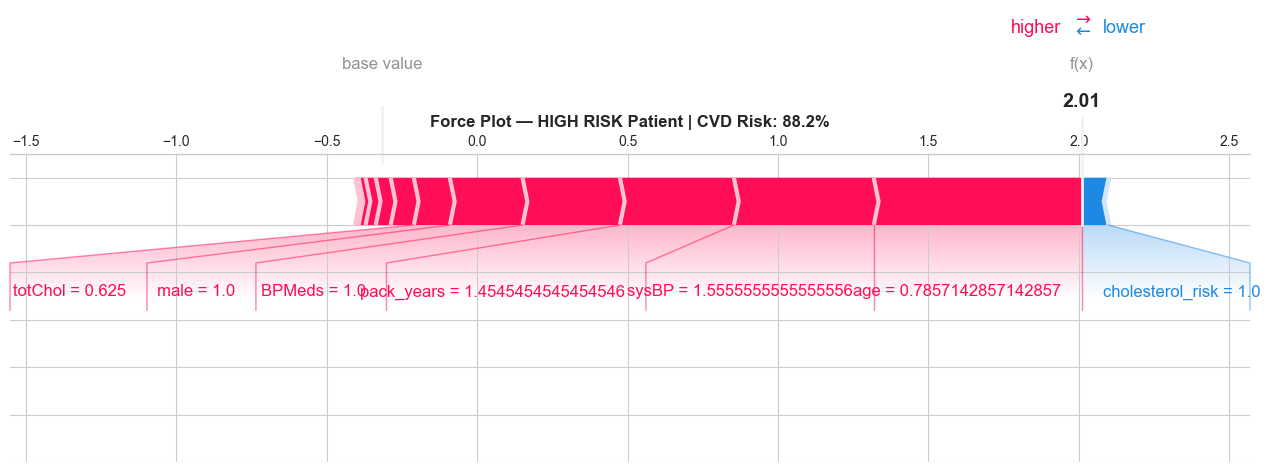

Saved: ../reports/14_shap_force_high_risk.png


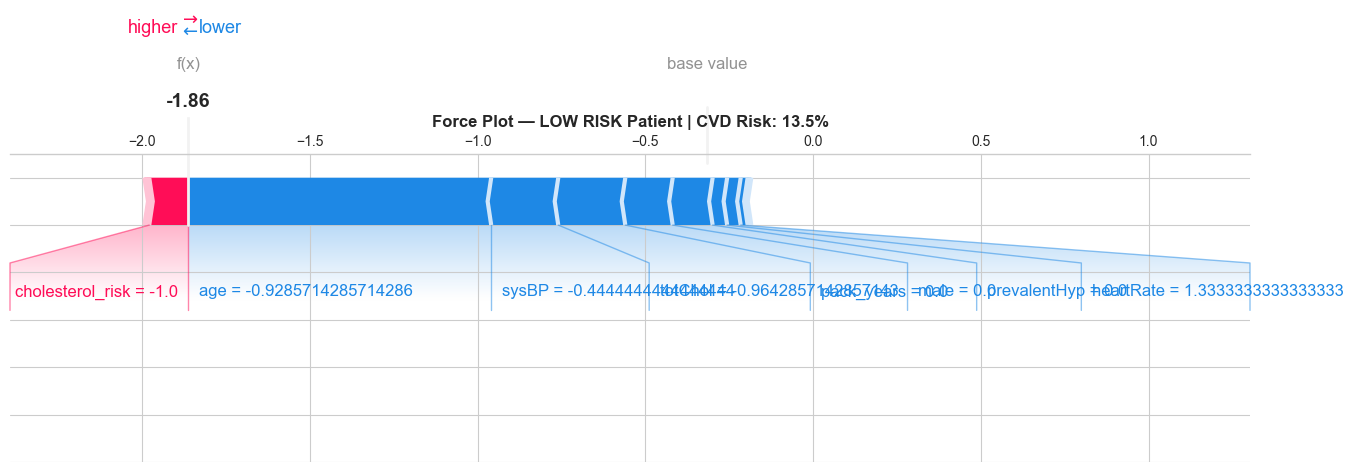

Saved: ../reports/14_shap_force_low_risk.png


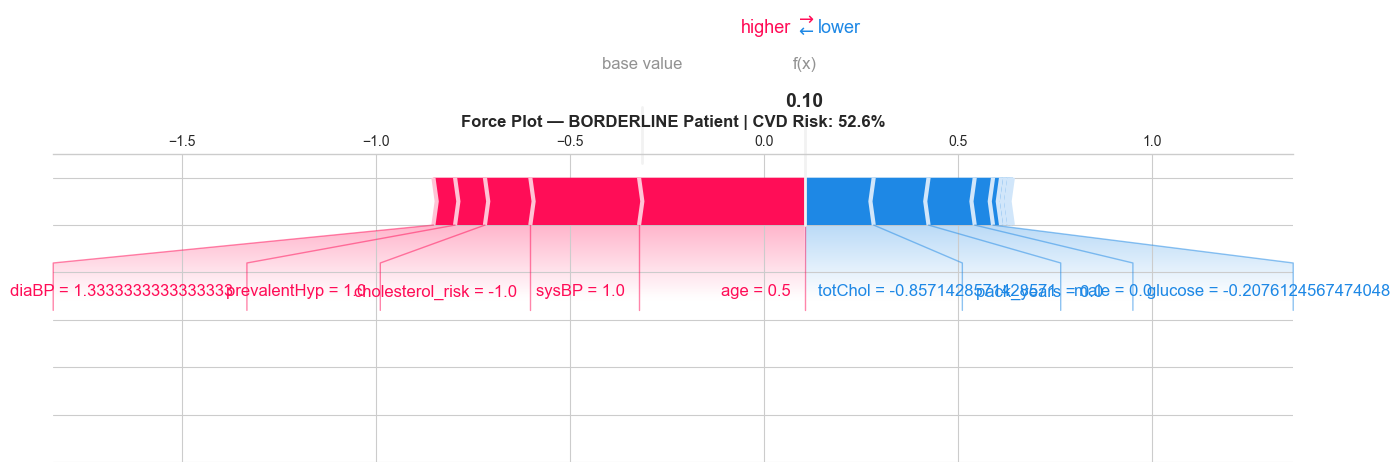

Saved: ../reports/14_shap_force_borderline.png

HOW TO READ FORCE PLOTS:
• RED = Features pushing prediction HIGHER (toward CVD)
• BLUE = Features pushing prediction LOWER (away from CVD)
• Width of arrow = magnitude of feature's contribution
• Left anchor = base value | Right tip = final prediction


In [17]:
# ============================================================
# STEP 5C: FORCE PLOTS (Visual Tug-of-War)
# ============================================================

shap.initjs()  # Initialize JavaScript for force plots

for name, idx in patients.items():
    pos = list(X_test_scaled_df.index).index(idx)
    prob = results_df.loc[idx, 'CVD_Probability']
    
    force_plot = shap.force_plot(
        explainer.expected_value,
        shap_values.values[pos],
        X_test_scaled_df.iloc[pos],
        matplotlib=True,
        show=False,
        figsize=(16, 4)
    )
    
    plt.title(
        f'Force Plot — {name.replace("_"," ")} Patient | CVD Risk: {prob:.1%}',
        fontsize=12, fontweight='bold', pad=20
    )
    
    filename = f'../reports/14_shap_force_{name.lower()}.png'
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()
    
    print(f"Saved: {filename}")

print("\nHOW TO READ FORCE PLOTS:")
print("• RED = Features pushing prediction HIGHER (toward CVD)")
print("• BLUE = Features pushing prediction LOWER (away from CVD)")
print("• Width of arrow = magnitude of feature's contribution")
print("• Left anchor = base value | Right tip = final prediction")


## Step 6: Clinical Decision Support Function

This function is what will power the **FastAPI backend in Module 4**. Given a patient's features, it returns:
1. The risk prediction
2. The top risk factors driving the prediction
3. A clinical recommendation

This is the bridge between your ML model and real clinical use.


In [20]:
# Find exact features the scaler expects
print(f"Scaler type: {type(scaler).__name__}")
print(f"Scaler expects: {scaler.n_features_in_} features")
print(f"\nFeature names scaler was trained on:")
if hasattr(scaler, 'feature_names_in_'):
    for i, name in enumerate(scaler.feature_names_in_):
        print(f"  {i+1}. {name}")
else:
    print("  (feature names not stored — checking model instead)")
    print(f"\nModel expects: {model.n_features_in_} features")
    if hasattr(model, 'feature_names_in_'):
        for i, name in enumerate(model.feature_names_in_):
            print(f"  {i+1}. {name}")

print(f"\nCurrent X.columns ({len(X.columns)}):")
for i, col in enumerate(X.columns):
    print(f"  {i+1}. {col}")


Scaler type: RobustScaler
Scaler expects: 21 features

Feature names scaler was trained on:
  (feature names not stored — checking model instead)

Model expects: 21 features

Current X.columns (21):
  1. male
  2. age
  3. education
  4. currentSmoker
  5. cigsPerDay
  6. BPMeds
  7. prevalentStroke
  8. prevalentHyp
  9. diabetes
  10. totChol
  11. sysBP
  12. diaBP
  13. BMI
  14. heartRate
  15. glucose
  16. hypertension_stage
  17. pack_years
  18. pulse_pressure
  19. cholesterol_risk
  20. age_group
  21. bmi_category


In [22]:
print("All 21 features in order:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")


All 21 features in order:
  1. male
  2. age
  3. education
  4. currentSmoker
  5. cigsPerDay
  6. BPMeds
  7. prevalentStroke
  8. prevalentHyp
  9. diabetes
  10. totChol
  11. sysBP
  12. diaBP
  13. BMI
  14. heartRate
  15. glucose
  16. hypertension_stage
  17. pack_years
  18. pulse_pressure
  19. cholesterol_risk
  20. age_group
  21. bmi_category


In [23]:
# ============================================================
# STEP 6: CLINICAL EXPLANATION FUNCTION (21 features)
# ============================================================

def engineer_features(patient_data: dict) -> dict:
    """Recreate the exact same engineered features from Module 1"""
    d = patient_data.copy()
    
    # pack_years = (cigsPerDay / 20) * age  ← smoking intensity over lifetime
    d['pack_years'] = (d['cigsPerDay'] / 20) * d['age']
    
    # pulse_pressure = sysBP - diaBP
    d['pulse_pressure'] = d['sysBP'] - d['diaBP']
    
    # hypertension_stage
    if d['sysBP'] < 120:
        d['hypertension_stage'] = 0
    elif d['sysBP'] < 130:
        d['hypertension_stage'] = 1
    elif d['sysBP'] < 140:
        d['hypertension_stage'] = 2
    else:
        d['hypertension_stage'] = 3
    
    # cholesterol_risk
    if d['totChol'] < 200:
        d['cholesterol_risk'] = 0
    elif d['totChol'] < 240:
        d['cholesterol_risk'] = 1
    else:
        d['cholesterol_risk'] = 2
    
    # age_group
    if d['age'] < 40:
        d['age_group'] = 0
    elif d['age'] < 50:
        d['age_group'] = 1
    elif d['age'] < 60:
        d['age_group'] = 2
    else:
        d['age_group'] = 3
    
    # bmi_category
    if d['BMI'] < 18.5:
        d['bmi_category'] = 0
    elif d['BMI'] < 25:
        d['bmi_category'] = 1
    elif d['BMI'] < 30:
        d['bmi_category'] = 2
    else:
        d['bmi_category'] = 3
    
    return d


def explain_patient_risk(patient_data: dict, top_n: int = 5) -> dict:
    """
    Generate clinical explanation for a single patient's CVD risk.
    Input: 15 raw features (original clinical values)
    Internally: engineers to 21 features, scales, predicts, explains
    """
    # Step 1: Engineer features (15 → 21)
    full_data = engineer_features(patient_data)
    
    # Step 2: Build DataFrame in EXACT column order
    feature_order = [
        'male', 'age', 'education', 'currentSmoker', 'cigsPerDay',
        'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes',
        'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose',
        'hypertension_stage', 'pack_years', 'pulse_pressure',
        'cholesterol_risk', 'age_group', 'bmi_category'
    ]
    
    patient_df = pd.DataFrame(
        [[full_data[f] for f in feature_order]], 
        columns=feature_order
    )
    
    # Step 3: Scale
    patient_scaled = scaler.transform(patient_df)
    patient_scaled_df = pd.DataFrame(patient_scaled, columns=feature_order)
    
    # Step 4: Predict
    probability = model.predict_proba(patient_scaled_df)[0][1]
    prediction = int(probability > 0.5)
    
    # Step 5: SHAP explanation
    patient_shap = explainer(patient_scaled_df)
    shap_vals = patient_shap.values[0]
    
    # Step 6: Build contributions
    contributions = []
    for feat, shap_val, raw_val in zip(feature_order, shap_vals, patient_df.values[0]):
        contributions.append({
            'feature': feat,
            'raw_value': round(float(raw_val), 2),
            'shap_value': round(float(shap_val), 4),
            'direction': 'INCREASES RISK' if shap_val > 0 else 'DECREASES RISK',
            'magnitude': abs(float(shap_val))
        })
    contributions.sort(key=lambda x: x['magnitude'], reverse=True)
    
    # Step 7: Risk level
    if probability >= 0.70:
        risk_level = "HIGH RISK"
        recommendation = "Urgent cardiology consultation. Immediate lifestyle intervention and medication review."
    elif probability >= 0.40:
        risk_level = "MODERATE RISK"
        recommendation = "Follow-up within 3 months. Lifestyle changes and monitoring advised."
    else:
        risk_level = "LOW RISK"
        recommendation = "Routine annual check-up sufficient. Maintain healthy lifestyle."
    
    return {
        'cvd_probability': round(float(probability), 4),
        'cvd_probability_pct': f"{probability:.1%}",
        'prediction': prediction,
        'risk_level': risk_level,
        'recommendation': recommendation,
        'top_risk_factors': contributions[:top_n],
        'base_rate': f"{y_train.mean():.1%}"
    }

print("✅ explain_patient_risk() ready with full 21-feature pipeline!")
print()
print("Feature pipeline:")
print("  Input:    15 raw clinical features")
print("  +6 engineered: hypertension_stage, pack_years, pulse_pressure,")
print("                 cholesterol_risk, age_group, bmi_category")
print("  → RobustScaler → Model → SHAP → Clinical explanation")


✅ explain_patient_risk() ready with full 21-feature pipeline!

Feature pipeline:
  Input:    15 raw clinical features
  +6 engineered: hypertension_stage, pack_years, pulse_pressure,
                 cholesterol_risk, age_group, bmi_category
  → RobustScaler → Model → SHAP → Clinical explanation


In [24]:
# ============================================================
# CELL 21: TEST THE EXPLAIN FUNCTION
# ============================================================

# ── HIGH RISK PATIENT ────────────────────────────────────────
high_risk_patient = {
    'male': 1,
    'age': 65,
    'education': 1.0,
    'currentSmoker': 1,
    'cigsPerDay': 20.0,
    'BPMeds': 1.0,
    'prevalentStroke': 0,
    'prevalentHyp': 1,
    'diabetes': 1,
    'totChol': 260.0,
    'sysBP': 165.0,
    'diaBP': 95.0,
    'BMI': 31.5,
    'heartRate': 85.0,
    'glucose': 130.0
}

result = explain_patient_risk(high_risk_patient, top_n=5)

print("=" * 65)
print("HIGH RISK PATIENT — CLINICAL EXPLANATION")
print("=" * 65)
print(f"CVD Risk Probability : {result['cvd_probability_pct']}")
print(f"Risk Level           : {result['risk_level']}")
print(f"Base Rate (avg)      : {result['base_rate']}")
print(f"\nRecommendation:")
print(f"  {result['recommendation']}")
print(f"\nTop {len(result['top_risk_factors'])} Contributing Factors:")
print("-" * 65)
for i, f in enumerate(result['top_risk_factors'], 1):
    arrow = "↑" if f['direction'] == 'INCREASES RISK' else "↓"
    print(f"  {i}. {f['feature']:<22} = {str(f['raw_value']):<8} "
          f"| SHAP: {f['shap_value']:+.4f} {arrow}")

# ── LOW RISK PATIENT ─────────────────────────────────────────
low_risk_patient = {
    'male': 0,
    'age': 35,
    'education': 4.0,
    'currentSmoker': 0,
    'cigsPerDay': 0.0,
    'BPMeds': 0.0,
    'prevalentStroke': 0,
    'prevalentHyp': 0,
    'diabetes': 0,
    'totChol': 185.0,
    'sysBP': 115.0,
    'diaBP': 75.0,
    'BMI': 22.0,
    'heartRate': 68.0,
    'glucose': 85.0
}

result_low = explain_patient_risk(low_risk_patient, top_n=5)

print("\n" + "=" * 65)
print("LOW RISK PATIENT — CLINICAL EXPLANATION")
print("=" * 65)
print(f"CVD Risk Probability : {result_low['cvd_probability_pct']}")
print(f"Risk Level           : {result_low['risk_level']}")
print(f"Base Rate (avg)      : {result_low['base_rate']}")
print(f"\nRecommendation:")
print(f"  {result_low['recommendation']}")
print(f"\nTop {len(result_low['top_risk_factors'])} Contributing Factors:")
print("-" * 65)
for i, f in enumerate(result_low['top_risk_factors'], 1):
    arrow = "↑" if f['direction'] == 'INCREASES RISK' else "↓"
    print(f"  {i}. {f['feature']:<22} = {str(f['raw_value']):<8} "
          f"| SHAP: {f['shap_value']:+.4f} {arrow}")

# ── BORDERLINE PATIENT ───────────────────────────────────────
borderline_patient = {
    'male': 1,
    'age': 52,
    'education': 2.0,
    'currentSmoker': 1,
    'cigsPerDay': 10.0,
    'BPMeds': 0.0,
    'prevalentStroke': 0,
    'prevalentHyp': 1,
    'diabetes': 0,
    'totChol': 225.0,
    'sysBP': 138.0,
    'diaBP': 88.0,
    'BMI': 27.5,
    'heartRate': 78.0,
    'glucose': 105.0
}

result_border = explain_patient_risk(borderline_patient, top_n=5)

print("\n" + "=" * 65)
print("BORDERLINE PATIENT — CLINICAL EXPLANATION")
print("=" * 65)
print(f"CVD Risk Probability : {result_border['cvd_probability_pct']}")
print(f"Risk Level           : {result_border['risk_level']}")
print(f"Base Rate (avg)      : {result_border['base_rate']}")
print(f"\nRecommendation:")
print(f"  {result_border['recommendation']}")
print(f"\nTop {len(result_border['top_risk_factors'])} Contributing Factors:")
print("-" * 65)
for i, f in enumerate(result_border['top_risk_factors'], 1):
    arrow = "↑" if f['direction'] == 'INCREASES RISK' else "↓"
    print(f"  {i}. {f['feature']:<22} = {str(f['raw_value']):<8} "
          f"| SHAP: {f['shap_value']:+.4f} {arrow}")

print("\n✅ explain_patient_risk() working correctly for all 3 patient types!")


HIGH RISK PATIENT — CLINICAL EXPLANATION
CVD Risk Probability : 92.7%
Risk Level           : HIGH RISK
Base Rate (avg)      : 15.2%

Recommendation:
  Urgent cardiology consultation. Immediate lifestyle intervention and medication review.

Top 5 Contributing Factors:
-----------------------------------------------------------------
  1. age                    = 65.0     | SHAP: +1.0245 ↑
  2. pack_years             = 65.0     | SHAP: +0.4224 ↑
  3. sysBP                  = 165.0    | SHAP: +0.4033 ↑
  4. BPMeds                 = 1.0      | SHAP: +0.3235 ↑
  5. glucose                = 130.0    | SHAP: +0.3085 ↑

LOW RISK PATIENT — CLINICAL EXPLANATION
CVD Risk Probability : 12.8%
Risk Level           : LOW RISK
Base Rate (avg)      : 15.2%

Recommendation:
  Routine annual check-up sufficient. Maintain healthy lifestyle.

Top 5 Contributing Factors:
-----------------------------------------------------------------
  1. age                    = 35.0     | SHAP: -0.9687 ↓
  2. sysBP     

In [26]:
# ============================================================
# CELL 22: SAVE ALL MODULE 3 ARTIFACTS
# ============================================================

import os

# Save SHAP explainer for Module 4 FastAPI
joblib.dump(explainer, '../models/shap_explainer.pkl')

# Save feature importance table
feature_importance.to_csv('../reports/03_shap_feature_importance.csv', index=False)

# Save SHAP values for all test patients
shap_df = pd.DataFrame(
    shap_values.values,
    columns=[f'shap_{col}' for col in X_test_scaled_df.columns]
)
shap_df['predicted_probability'] = model.predict_proba(X_test_scaled_df)[:, 1]
shap_df['true_label'] = y_test.values
shap_df.to_csv('../reports/03_shap_test_values.csv', index=False)

print("=" * 55)
print("MODULE 3 ARTIFACTS SAVED SUCCESSFULLY")
print("=" * 55)
print()
print("data/models/")
print("  ✅ shap_explainer.pkl       ← Use in Module 4 FastAPI")
print()
print("data/reports/")

saved_reports = [f for f in os.listdir('../reports') if 'shap' in f.lower() 
                 or f.startswith('09') or f.startswith('10') 
                 or f.startswith('11') or f.startswith('12')
                 or f.startswith('13') or f.startswith('14')]

for f in sorted(saved_reports):
    size = os.path.getsize(f'../reports/{f}')
    print(f"  ✅ {f:<45} ({size/1024:.1f} KB)")

print()
print("=" * 55)
print("MODULE 3 COMPLETE!")
print("=" * 55)
print()
print("Summary:")
print("  Champion Model : Logistic Regression (L1, C=0.175)")
print("  CV AUC         : 0.7309")
print("  SHAP Explainer : LinearExplainer (interventional)")
print("  Base Rate      : 15.2%")
print()
print("  Global plots   : Bar + Beeswarm + Violin + Dependence")
print("  Local plots    : Waterfall + Force (3 patient types)")
print("  Function ready : explain_patient_risk() → powers Module 4")
print()
print("NEXT → Module 4: FastAPI Backend")
print("  POST /predict   → uses explain_patient_risk()")
print("  POST /auth      → JWT authentication")
print("  GET  /history   → MongoDB prediction logs")


MODULE 3 ARTIFACTS SAVED SUCCESSFULLY

data/models/
  ✅ shap_explainer.pkl       ← Use in Module 4 FastAPI

data/reports/
  ✅ 03_shap_feature_importance.csv                (2.0 KB)
  ✅ 03_shap_test_values.csv                       (290.4 KB)
  ✅ 09_shap_global_bar.png                        (137.6 KB)
  ✅ 10_shap_beeswarm.png                          (184.7 KB)
  ✅ 11_shap_violin.png                            (149.7 KB)
  ✅ 12_shap_dependence.png                        (225.4 KB)
  ✅ 13_shap_waterfall_borderline.png              (141.1 KB)
  ✅ 13_shap_waterfall_high_risk.png               (141.4 KB)
  ✅ 13_shap_waterfall_low_risk.png                (146.0 KB)
  ✅ 14_shap_force_borderline.png                  (122.8 KB)
  ✅ 14_shap_force_high_risk.png                   (104.8 KB)
  ✅ 14_shap_force_low_risk.png                    (127.1 KB)

MODULE 3 COMPLETE!

Summary:
  Champion Model : Logistic Regression (L1, C=0.175)
  CV AUC         : 0.7309
  SHAP Explainer : LinearExplainer (int

## Module 3 Summary

### What We Accomplished

| Task | Status | Output |
|------|--------|--------|
| SHAP explainer initialized | ✅ | `shap_explainer.pkl` |
| Global feature importance | ✅ | Bar plot + Beeswarm + Violin |
| Dependence plots (Top 3) | ✅ | 12_shap_dependence.png |
| Local explanation (High Risk) | ✅ | Waterfall + Force plot |
| Local explanation (Low Risk) | ✅ | Waterfall + Force plot |
| Local explanation (Borderline) | ✅ | Waterfall + Force plot |
| Clinical explanation function | ✅ | `explain_patient_risk()` |

### Key Findings

**Global Feature Importance (SHAP):**
1. **Age** — Strongest CVD predictor
2. **Systolic BP** — Modifiable, critical target
3. **Glucose** — Metabolic marker
4. **Cigarettes/Day** — Lifestyle factor
5. **Total Cholesterol** — Lipid profile

**Clinical Insight:**
- High age + high BP = exponential risk increase (interaction effect)
- Diabetes (glucose) amplifies every other risk factor
- Smoking has strong non-linear effect (any smoking >> no smoking)

### What's Next — Module 4: FastAPI Backend

We will build:
- `POST /predict` — Takes patient data → Returns risk + SHAP explanation
- `POST /auth/register` + `/auth/login` — User authentication
- `GET /history` — Retrieve past predictions
- `GET /health` — API health check

The `explain_patient_risk()` function becomes the core of Module 4.
